# KIVI KV-Cache SVD Analysis — GPT-2 Large

**Model:** `gpt2-large` — no auth required. Verified architecture: **36 layers**, **20 attention heads** (satisfies >16), head-dim 64, hidden 1280, true multi-head attention (no GQA — `num_key_value_heads == num_attention_heads`). Max context 1024.

**Target runtime:** Google Colab Pro, **NVIDIA L4** (24 GB).

**Pipeline:**
1. Load `gpt2-large`.
2. Run a long, topically-diverse prompt (≈1024 tokens) to collect per-layer K and V caches of shape `(B=1, H=20, T, D=64)`.
3. Reshape into KIVI's `X ∈ ℝ^(T × d)` view with `d = H·D = 1280`.
4. Apply **KIVI group-wise quantization scaling** (paper §3.1, §3.3, Algorithm 1) with `group_size G = 32`, `bits = 2`:
   - **K: group-wise per-channel** — groups of G tokens × every channel get their own `(min, max, scale, zero)`.
   - **V: group-wise per-token** — every token × groups of G channels get their own `(min, max, scale, zero)`.
   - Produce `X_scaled = (X − z) / s` ∈ `[0, 2^B−1]` (the integer-range representation before rounding).
5. SVD each layer's scaled K and V matrices.
6. Plot two figures × {K, V}:
   - Frobenius energy captured vs. layer index at ranks **1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 32**.
   - Normalised singular value decay per layer, log y-axis.

## 1. Environment

In [1]:
# !pip install -q --upgrade transformers 2>&1 | tail -n 1
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [2]:
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

torch.manual_seed(1229)
np.random.seed(1229)

DEVICE = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
DTYPE  = torch.float16 if DEVICE == 'cuda' else torch.float32
print(f'Device : {DEVICE}')
print(f'dtype  : {DTYPE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : mps
dtype  : torch.float32


## 2. Load `gpt2-large`

Verifying the architecture meets our requirement of >16 heads.

In [3]:
MODEL_ID = 'gpt2-large'

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    low_cpu_mem_usage=True,
).to(DEVICE)
model.eval()

cfg = model.config
NUM_LAYERS = cfg.n_layer
NUM_HEADS  = cfg.n_head
HIDDEN     = cfg.n_embd
HEAD_DIM   = HIDDEN // NUM_HEADS
MAX_CTX    = cfg.n_positions

print(f'Model       : {MODEL_ID}')
print(f'Layers      : {NUM_LAYERS}')
print(f'Heads       : {NUM_HEADS}   (Q/K/V all equal — no GQA)')
print(f'Head dim    : {HEAD_DIM}')
print(f'd = H·D     : {NUM_HEADS * HEAD_DIM}')
print(f'Max context : {MAX_CTX}')

assert NUM_HEADS > 16, 'Need >16 heads.'
print('\n✓ >16 heads satisfied (no GQA — K/V heads match attention heads).')

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model       : gpt2-large
Layers      : 36
Heads       : 20   (Q/K/V all equal — no GQA)
Head dim    : 64
d = H·D     : 1280
Max context : 1024

✓ >16 heads satisfied (no GQA — K/V heads match attention heads).


## 3. Long, topically-diverse input

Non-repeating context built from 10 different subject passages (history, physics, biology, music, cooking, programming, astronomy, literature, philosophy, art history). Truncated to GPT-2's 1024-token ceiling.

In [4]:
passages = [
    "The signing of the Magna Carta at Runnymede in June 1215 curtailed the arbitrary powers of King John of England. "
    "Though most of its clauses concerned feudal dues, the document became a cornerstone of later constitutional thought. "
    "English lawyers repeatedly invoked its guarantees against tyranny, and jurists in colonial America cited it when drafting the Bill of Rights. "
    "Its legacy persists through habeas corpus, due process, and the notion that rulers themselves are subject to law.",

    "Quantum entanglement describes a correlation between particles such that the quantum state of each cannot be described independently. "
    "When two photons are prepared in a singlet state and sent along separate fibres, a measurement of polarization on one instantly determines the outcome of the corresponding measurement on the other, regardless of distance. "
    "Bell's theorem showed that no local hidden-variable theory can reproduce these correlations; experiments by Aspect, Zeilinger, and Clauser have confirmed the predictions, earning the 2022 Nobel Prize in Physics.",

    "Mitochondria are double-membraned organelles responsible for oxidative phosphorylation in eukaryotic cells. "
    "Their inner membrane hosts the electron transport chain, where NADH and FADH2 donate electrons that flow through complexes I to IV, pumping protons into the intermembrane space. "
    "The resulting electrochemical gradient drives ATP synthase, producing the adenosine triphosphate that fuels muscle contraction, neuronal firing, biosynthesis, and active membrane transport.",

    "Johann Sebastian Bach composed The Well-Tempered Clavier as a collection of preludes and fugues traversing all twenty-four major and minor keys. "
    "The first book, completed in Koethen in 1722, was intended partly as a pedagogical resource for his sons and students. "
    "Its contrapuntal intricacy — layered voices, inversions, strettos, and augmentations — influenced composers as varied as Mozart, Chopin, and Shostakovich, whose own cycle of preludes and fugues pays direct homage.",

    "A proper risotto alla Milanese begins with softened shallots in butter, then toasting Carnaroli rice until the edges turn translucent. "
    "A splash of dry white wine is absorbed before warm saffron-infused stock is added ladle by ladle, each addition stirred gently until the starch releases. "
    "The dish finishes with a vigorous mantecatura — beating in cold butter and grated Parmigiano off the heat — producing the creamy wave-like consistency known as all'onda.",

    "The Rust borrow checker enforces memory safety without a garbage collector by tracking ownership of every value at compile time. "
    "When a value is moved the original binding becomes invalid; references are either shared and immutable or exclusive and mutable, but never both simultaneously. "
    "This discipline eliminates data races and use-after-free bugs at the type level, though newcomers often find the learning curve steep before the rules begin to feel natural.",

    "Pulsars are rapidly rotating neutron stars emitting beams of electromagnetic radiation from their magnetic poles. "
    "As the beam sweeps past Earth, observers detect periodic pulses whose timing regularity rivals atomic clocks. "
    "The first pulsar, CP 1919, was discovered by Jocelyn Bell Burnell in 1967; pulsars have since enabled precision tests of general relativity in strong fields, most notably through the Hulse-Taylor binary and the later double-pulsar system J0737-3039.",

    "Virginia Woolf's stream-of-consciousness technique in Mrs Dalloway renders a single June day in post-war London through the shifting perceptions of Clarissa Dalloway and the shell-shocked veteran Septimus Warren Smith. "
    "The narrative moves fluidly between minds, mediated by the tolling of Big Ben, producing a prose texture that critics have compared to musical counterpoint. "
    "Woolf drafted the novel amid her own struggles with mental illness, and the psychological realism of Septimus's breakdown drew on her direct experience.",

    "Aristotle distinguishes in the Nicomachean Ethics between intellectual and moral virtues. "
    "Intellectual virtues arise from teaching, whereas moral virtues form through habituation: we become just by performing just actions, temperate by acting temperately. "
    "The doctrine of the mean holds that virtue lies between excess and deficiency — courage between cowardice and recklessness, generosity between miserliness and prodigality — with practical wisdom, phronesis, guiding the calibration.",

    "Caravaggio's tenebrism, developed in late sixteenth-century Rome, uses stark contrast between brightly illuminated figures and deep, almost absolute shadow. "
    "In works such as The Calling of Saint Matthew and Supper at Emmaus, a single raking light source models flesh and fabric with theatrical force while the backgrounds dissolve into darkness. "
    "This chiaroscuro influenced a generation of painters from Gentileschi and Ribera to Georges de La Tour and, indirectly, Rembrandt.",
]

text = ' '.join(passages)
print(f'Characters: {len(text)}')
print(text[:260], '...')

Characters: 4897
The signing of the Magna Carta at Runnymede in June 1215 curtailed the arbitrary powers of King John of England. Though most of its clauses concerned feudal dues, the document became a cornerstone of later constitutional thought. English lawyers repeatedly inv ...


In [5]:
# Tokenize and cap to GPT-2's context ceiling.
enc = tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_CTX)
input_ids = enc.input_ids.to(DEVICE)
T = input_ids.shape[1]
print(f'Token count T = {T}  (GPT-2 max = {MAX_CTX})')

Token count T = 983  (GPT-2 max = 1024)


## 4. Forward pass — capture per-layer K/V caches

GPT-2's HuggingFace implementation returns `past_key_values` as a tuple of `(K, V)` tensors per layer, each of shape `(batch, num_heads, seq_len, head_dim)`. Newer versions wrap this in a `DynamicCache` object — we handle both.

In [6]:
with torch.no_grad():
    out = model(input_ids=input_ids, use_cache=True, return_dict=True)

past = out.past_key_values

# DynamicCache -> legacy tuple of (K, V) pairs
if hasattr(past, 'to_legacy_cache'):
    past = past.to_legacy_cache()

# Move to CPU + float32 for stable SVD (SVD of fp16 is numerically poor).
# kv_layers = []
# for (K, V) in past:
#     kv_layers.append((K.detach().float().cpu(), V.detach().float().cpu()))

# # Sanity-check shapes.
# K0, V0 = kv_layers[0]
# print(f'Num layers captured : {len(kv_layers)}')
# print(f'Layer-0 K shape     : {tuple(K0.shape)}  (B, H, T, D)')
# print(f'Layer-0 V shape     : {tuple(V0.shape)}  (B, H, T, D)')
# assert K0.shape == (1, NUM_HEADS, T, HEAD_DIM), 'unexpected K shape'
# assert V0.shape == (1, NUM_HEADS, T, HEAD_DIM), 'unexpected V shape'
# print('\n✓ K/V tensors extracted correctly.')
with torch.no_grad():
    out = model(input_ids=input_ids, use_cache=True, return_dict=True)

past = out.past_key_values

with torch.no_grad():
    out = model(input_ids=input_ids, use_cache=True, return_dict=True)

past = out.past_key_values

def extract_kv_pairs(past_obj):
    # New DynamicCache: .layers[i].keys / .layers[i].values
    if hasattr(past_obj, 'layers') and past_obj.layers is not None and len(past_obj.layers) > 0:
        pairs = []
        for layer in past_obj.layers:
            if hasattr(layer, 'keys') and hasattr(layer, 'values'):
                pairs.append((layer.keys, layer.values))
            elif isinstance(layer, (tuple, list)) and len(layer) == 2:
                pairs.append((layer[0], layer[1]))
            else:
                raise RuntimeError(f'Unknown layer object type: {type(layer)}')
        return pairs
    # Older DynamicCache: parallel .key_cache / .value_cache lists
    if hasattr(past_obj, 'key_cache') and hasattr(past_obj, 'value_cache'):
        return list(zip(past_obj.key_cache, past_obj.value_cache))
    # Legacy tuple-of-tuples
    try:
        return [(p[0], p[1]) for p in past_obj]
    except Exception as e:
        raise RuntimeError(f'Could not extract K/V from {type(past_obj)}: {e}')

raw_pairs = extract_kv_pairs(past)
print(f'Extracted {len(raw_pairs)} (K, V) pairs from {type(past).__name__}')

kv_layers = [(K.detach().float().cpu(), V.detach().float().cpu()) for (K, V) in raw_pairs]

K0, V0 = kv_layers[0]
print(f'Num layers captured : {len(kv_layers)}')
print(f'Layer-0 K shape     : {tuple(K0.shape)}  (B, H, T, D)')
print(f'Layer-0 V shape     : {tuple(V0.shape)}  (B, H, T, D)')
assert K0.shape == (1, NUM_HEADS, T, HEAD_DIM), 'unexpected K shape'
assert V0.shape == (1, NUM_HEADS, T, HEAD_DIM), 'unexpected V shape'
print('\n✓ K/V tensors extracted correctly.')

Extracted 36 (K, V) pairs from DynamicCache
Num layers captured : 36
Layer-0 K shape     : (1, 20, 983, 64)  (B, H, T, D)
Layer-0 V shape     : (1, 20, 983, 64)  (B, H, T, D)

✓ K/V tensors extracted correctly.


## 5. KIVI's matrix view and group-wise scaling

**Matrix view** (paper Fig. 1, §2): `X ∈ ℝ^(T × d)` where `d = H · head_dim = 1280`. Rows are tokens, columns are channels.

**Group size & bits** (paper §4.1): `G = 32`, `B = 2` bits → `q_max = 2^B − 1 = 3`.

**Quantization op** (paper §3.1):

$$ s_X = \frac{\max X - \min X}{2^B - 1}, \quad z_X = \min X, \quad Q(X) = \left\lfloor \frac{X - z_X}{s_X} \right\rceil $$

**Group layout** (paper Algorithm 1):
- **K, group-wise per-channel**: scales computed across groups of `G` tokens along the **token axis**, *independently per channel*. Produces `(T/G, d)` scale/zero grids.
- **V, group-wise per-token**: scales computed across groups of `G` channels along the **channel axis**, *independently per token*. Produces `(T, d/G)` scale/zero grids.

We drop the rounding step for the SVD analysis — we keep the continuous scaled representation `X_scaled = (X − z) / s`, which lives in `[0, q_max]`. This is the representation whose low-rank structure we care about.

In [7]:
GROUP_SIZE = 32
BITS = 2
QMAX = (2 ** BITS) - 1  # 3
EPS  = 1e-8

def to_Txd(kv):
    """(1, H, T, D) -> (T, H*D) in KIVI's X ∈ R^(T×d) view.
    Channel index = head_idx * D + dim_idx."""
    assert kv.shape[0] == 1, 'batch==1'
    _, H, T, D = kv.shape
    return kv[0].permute(1, 0, 2).reshape(T, H * D).contiguous()

def kivi_K_scaled(K_Txd, G, qmax, eps=EPS):
    """KIVI per-channel group quantisation scaling for K.
    Groups G tokens along dim=0 (token axis), independently per channel (dim=1).
    Requires T % G == 0; we truncate to the nearest multiple.
    Returns X_scaled ∈ [0, qmax]."""
    T, d = K_Txd.shape
    T_trim = (T // G) * G
    X = K_Txd[:T_trim]                                 # (T_trim, d)
    X = X.reshape(T_trim // G, G, d)                   # (num_groups, G, d)
    x_min = X.amin(dim=1, keepdim=True)                # (num_groups, 1, d)
    x_max = X.amax(dim=1, keepdim=True)
    scale = (x_max - x_min) / qmax + eps               # (num_groups, 1, d)
    zero  = x_min
    Xs = (X - zero) / scale                            # (num_groups, G, d) in [0, qmax]
    return Xs.reshape(T_trim, d), T_trim

def kivi_V_scaled(V_Txd, G, qmax, eps=EPS):
    """KIVI per-token group quantisation scaling for V.
    Groups G channels along dim=1 (channel axis), independently per token (dim=0).
    Requires d % G == 0 (d = H*head_dim; 1280 % 32 == 0 for gpt2-large).
    Returns X_scaled ∈ [0, qmax]."""
    T, d = V_Txd.shape
    assert d % G == 0, f'd={d} not divisible by G={G}'
    X = V_Txd.reshape(T, d // G, G)                    # (T, num_groups, G)
    x_min = X.amin(dim=2, keepdim=True)                # (T, num_groups, 1)
    x_max = X.amax(dim=2, keepdim=True)
    scale = (x_max - x_min) / qmax + eps
    zero  = x_min
    Xs = (X - zero) / scale                            # (T, num_groups, G) in [0, qmax]
    return Xs.reshape(T, d)

# Sanity check on layer 0.
K0_m = to_Txd(kv_layers[0][0])
V0_m = to_Txd(kv_layers[0][1])
K0_s, T_trim0 = kivi_K_scaled(K0_m, GROUP_SIZE, QMAX)
V0_s           = kivi_V_scaled(V0_m, GROUP_SIZE, QMAX)
print(f'Layer-0 K (T×d)       : {tuple(K0_m.shape)}')
print(f'Layer-0 V (T×d)       : {tuple(V0_m.shape)}')
print(f'K scaled shape        : {tuple(K0_s.shape)}   trimmed to multiple of G={GROUP_SIZE}')
print(f'V scaled shape        : {tuple(V0_s.shape)}')
print(f'K scaled range        : [{K0_s.min():.3f}, {K0_s.max():.3f}]   (target [0, {QMAX}])')
print(f'V scaled range        : [{V0_s.min():.3f}, {V0_s.max():.3f}]')

Layer-0 K (T×d)       : (983, 1280)
Layer-0 V (T×d)       : (983, 1280)
K scaled shape        : (960, 1280)   trimmed to multiple of G=32
V scaled shape        : (983, 1280)
K scaled range        : [0.000, 3.000]   (target [0, 3])
V scaled range        : [0.000, 3.000]


## 6. SVD per layer

Compute singular values of `K_scaled` and `V_scaled` for every layer using `torch.linalg.svdvals` (no U, Vt — cheaper and numerically fine). Double precision for stability.

In [8]:
def svdvals(mat):
    return torch.linalg.svdvals(mat.double()).cpu().numpy()

sv_K = []
sv_V = []

for i, (K, V) in enumerate(kv_layers):
    K_Txd = to_Txd(K)
    V_Txd = to_Txd(V)
    K_s, _ = kivi_K_scaled(K_Txd, GROUP_SIZE, QMAX)
    V_s    = kivi_V_scaled(V_Txd, GROUP_SIZE, QMAX)
    sv_K.append(svdvals(K_s))
    sv_V.append(svdvals(V_s))
    if i % 6 == 0 or i == NUM_LAYERS - 1:
        print(f'Layer {i:02d}: K_scaled {tuple(K_s.shape)}  V_scaled {tuple(V_s.shape)}  '
              f'| #sv(K)={len(sv_K[-1])}  #sv(V)={len(sv_V[-1])}')

print(f'\n✓ SVD complete for all {NUM_LAYERS} layers.')

Layer 00: K_scaled (960, 1280)  V_scaled (983, 1280)  | #sv(K)=960  #sv(V)=983
Layer 06: K_scaled (960, 1280)  V_scaled (983, 1280)  | #sv(K)=960  #sv(V)=983
Layer 12: K_scaled (960, 1280)  V_scaled (983, 1280)  | #sv(K)=960  #sv(V)=983
Layer 18: K_scaled (960, 1280)  V_scaled (983, 1280)  | #sv(K)=960  #sv(V)=983
Layer 24: K_scaled (960, 1280)  V_scaled (983, 1280)  | #sv(K)=960  #sv(V)=983
Layer 30: K_scaled (960, 1280)  V_scaled (983, 1280)  | #sv(K)=960  #sv(V)=983
Layer 35: K_scaled (960, 1280)  V_scaled (983, 1280)  | #sv(K)=960  #sv(V)=983

✓ SVD complete for all 36 layers.


## 7. Frobenius energy at each rank

Energy captured by rank-r approximation:

$$\mathrm{energy}(r) = \frac{\sum_{i=1}^{r} \sigma_i^2}{\sum_{i=1}^{\min(M,N)} \sigma_i^2} \times 100\%$$

In [9]:
RANKS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 32]

def energy_at_ranks(sv_list, ranks):
    out = np.zeros((len(sv_list), len(ranks)))
    for li, sv in enumerate(sv_list):
        sq = sv.astype(np.float64) ** 2
        total = sq.sum()
        for ri, r in enumerate(ranks):
            r_eff = min(r, len(sv))
            out[li, ri] = sq[:r_eff].sum() / total * 100.0
    return out

energy_K = energy_at_ranks(sv_K, RANKS)
energy_V = energy_at_ranks(sv_V, RANKS)

print('Average Frobenius energy captured (averaged across layers):\n')
print(f'{"rank":>5} | {"K-scaled %":>12} | {"V-scaled %":>12}')
print('-' * 40)
for ri, r in enumerate(RANKS):
    print(f'{r:>5d} | {energy_K[:, ri].mean():>12.2f} | {energy_V[:, ri].mean():>12.2f}')

Average Frobenius energy captured (averaged across layers):

 rank |   K-scaled % |   V-scaled %
----------------------------------------
    1 |        79.90 |        81.34
    2 |        81.35 |        82.41
    3 |        82.38 |        83.05
    4 |        83.16 |        83.56
    5 |        83.77 |        84.00
    6 |        84.30 |        84.38
    7 |        84.76 |        84.74
    8 |        85.17 |        85.05
    9 |        85.53 |        85.34
   10 |        85.86 |        85.61
   15 |        87.17 |        86.71
   20 |        88.13 |        87.55
   25 |        88.91 |        88.25
   32 |        89.79 |        89.08


## 8. Plot 1 — energy captured vs. layer index

Matches the style of your reference plot: one curve per rank, 50% and 30% reference lines.

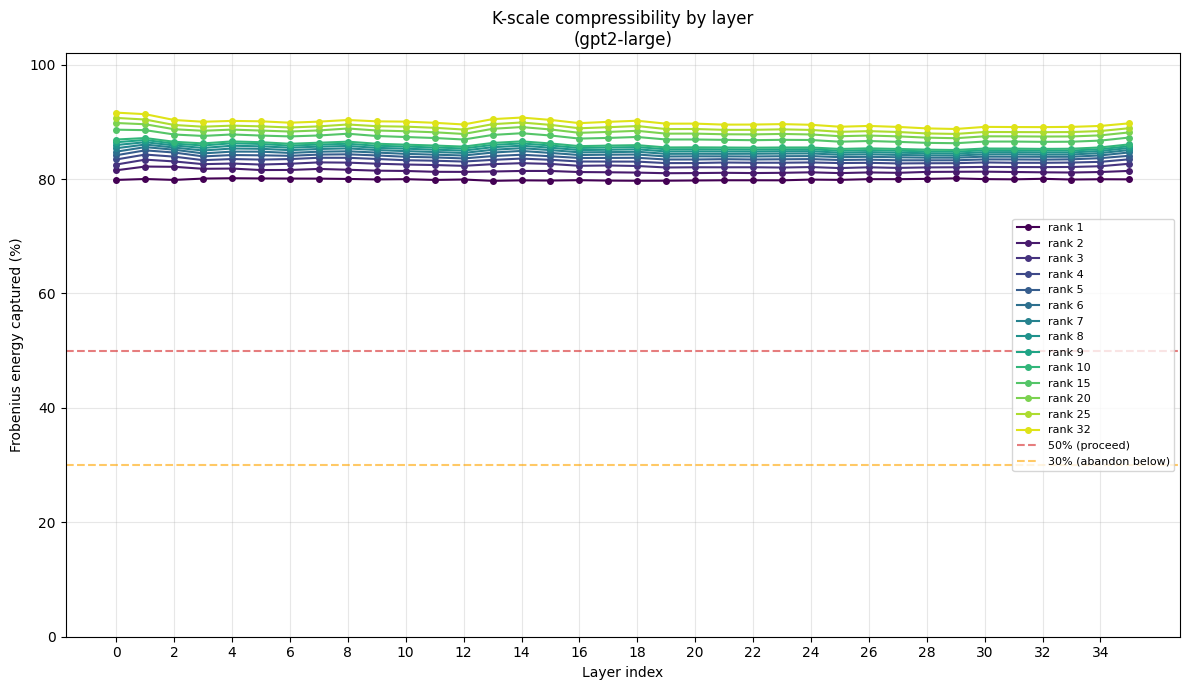

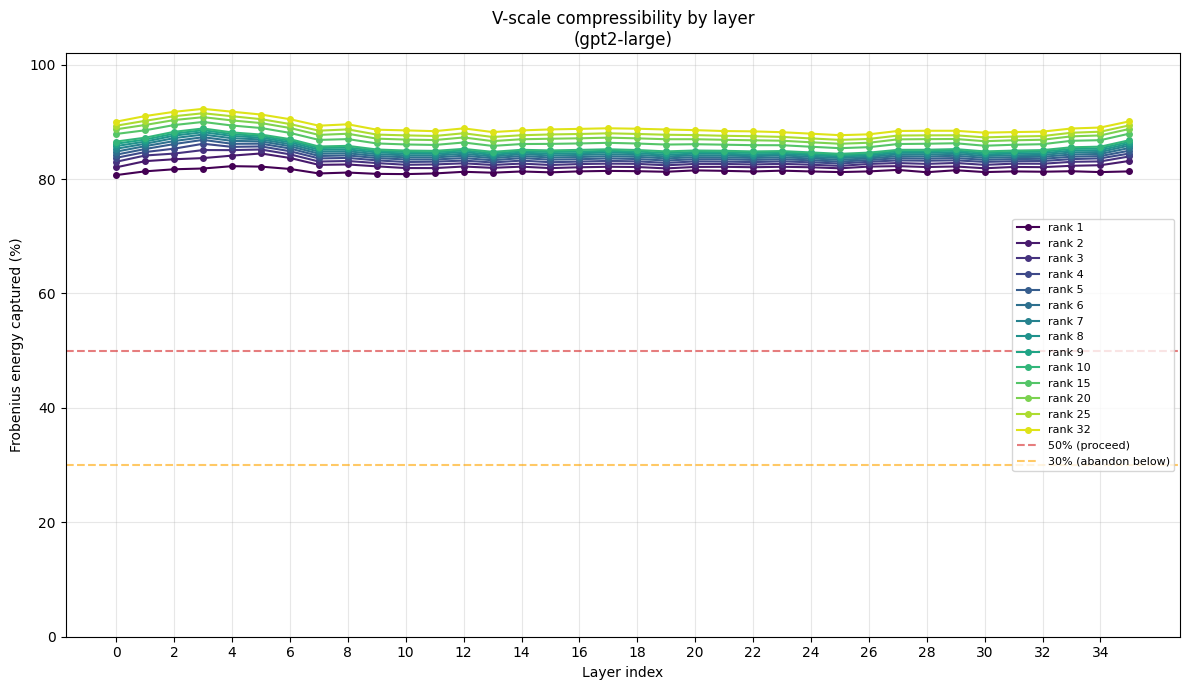

In [10]:
def plot_energy_by_layer(energy, ranks, which, savepath):
    fig, ax = plt.subplots(figsize=(12, 7))
    num_layers = energy.shape[0]
    xs = np.arange(num_layers)
    cmap = plt.cm.viridis(np.linspace(0, 0.95, len(ranks)))

    for ri, r in enumerate(ranks):
        ax.plot(xs, energy[:, ri], marker='o', linewidth=1.5, markersize=4,
                color=cmap[ri], label=f'rank {r}')

    ax.axhline(50, color='tab:red',  linestyle='--', alpha=0.6, label='50% (proceed)')
    ax.axhline(30, color='orange',   linestyle='--', alpha=0.6, label='30% (abandon below)')

    ax.set_xlabel('Layer index')
    ax.set_ylabel('Frobenius energy captured (%)')
    ax.set_title(f'{which}-scale compressibility by layer\n({MODEL_ID})')
    ax.set_ylim(0, 102)
    ax.set_xticks(xs[::2])
    ax.grid(True, alpha=0.3)
    ax.legend(loc='center right', ncol=1, fontsize=8)
    plt.tight_layout()
    plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()

plot_energy_by_layer(energy_K, RANKS, 'K', 'energy_by_layer_K.png')
plot_energy_by_layer(energy_V, RANKS, 'V', 'energy_by_layer_V.png')

## 9. Plot 2 — singular-value decay per layer (log scale)

Each layer's singular values are divided by its largest (so every curve starts at 1.0), then plotted on a log y-axis. A handful of layers are highlighted to keep the plot readable.

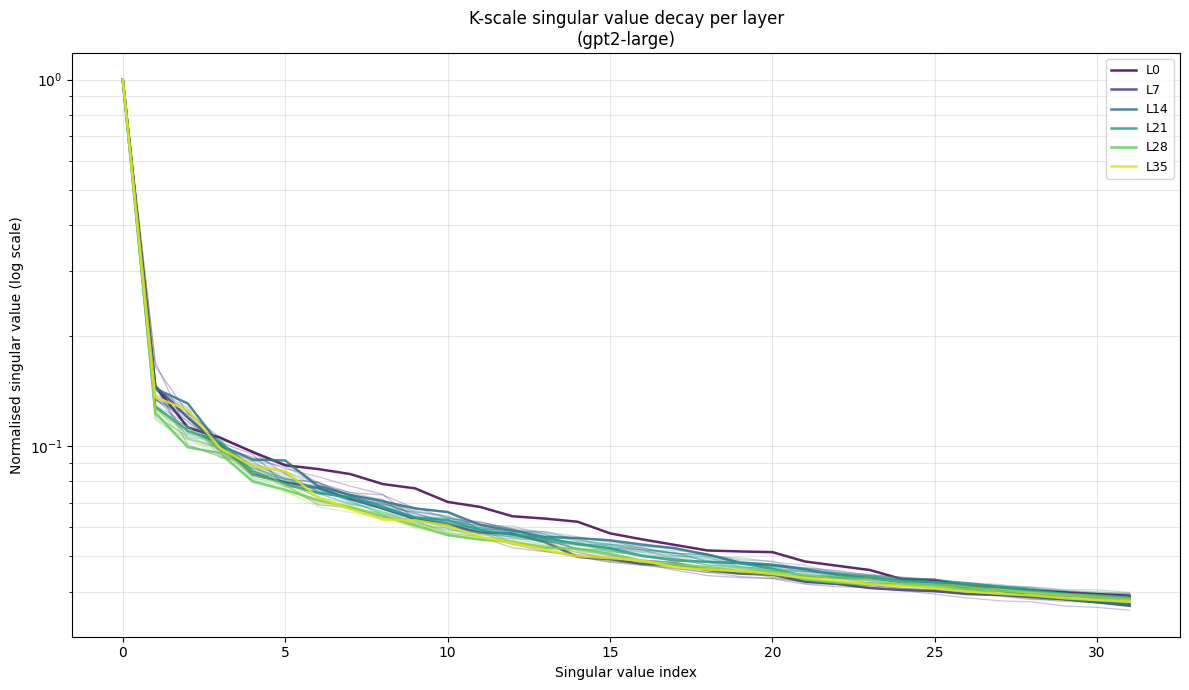

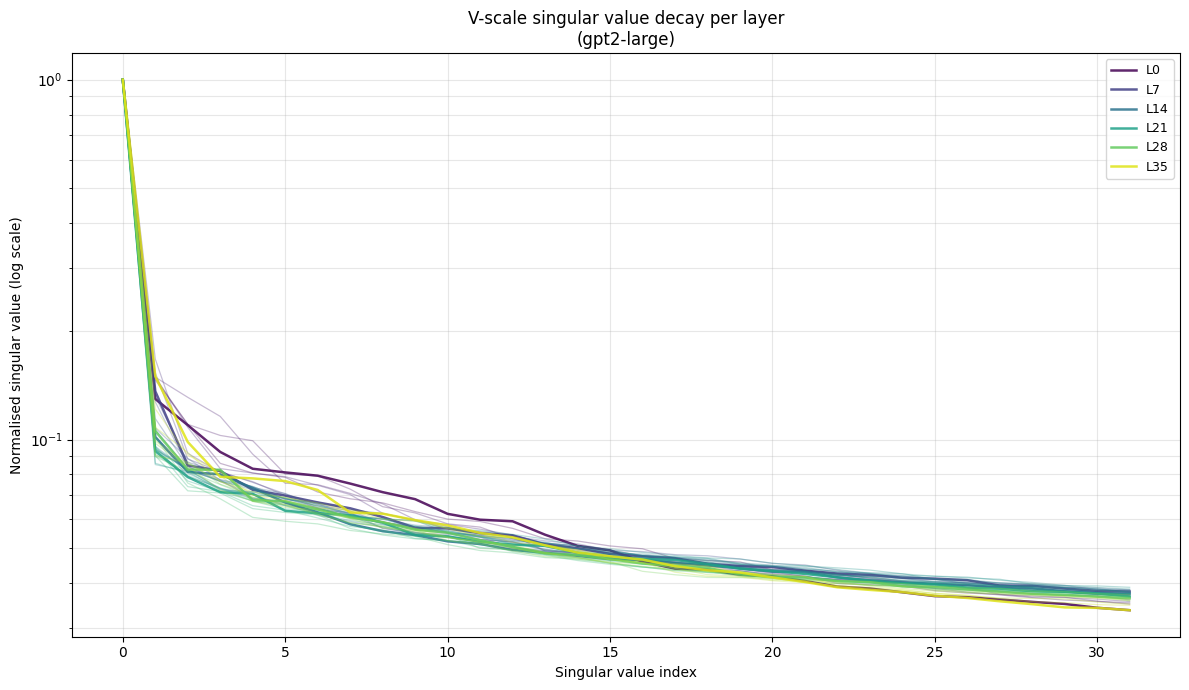

In [11]:
HIGHLIGHT = [0, 7, 14, 21, 28, 35]   # spread across 36 gpt2-large layers
MAX_SV = 32

def plot_sv_decay(sv_list, which, savepath, max_sv=MAX_SV):
    fig, ax = plt.subplots(figsize=(12, 7))
    n = len(sv_list)
    cmap = plt.cm.viridis(np.linspace(0, 0.95, n))

    for li, sv in enumerate(sv_list):
        sv_n = sv[:max_sv] / sv[0]
        xs = np.arange(len(sv_n))
        is_hi = li in HIGHLIGHT
        ax.plot(xs, sv_n,
                color=cmap[li],
                alpha=0.85 if is_hi else 0.30,
                linewidth=1.8 if is_hi else 0.9,
                label=f'L{li}' if is_hi else None)

    ax.set_yscale('log')
    ax.set_xlabel('Singular value index')
    ax.set_ylabel('Normalised singular value (log scale)')
    ax.set_title(f'{which}-scale singular value decay per layer\n({MODEL_ID})')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()

plot_sv_decay(sv_K, 'K', 'singular_value_decay_K.png')
plot_sv_decay(sv_V, 'V', 'singular_value_decay_V.png')

## 10. Summary

Files written:
- `energy_by_layer_K.png`, `energy_by_layer_V.png`
- `singular_value_decay_K.png`, `singular_value_decay_V.png`

What the plots show:
- **Energy by layer**: at what rank (out of `min(T, d)` singular values) we capture 30%, 50%, 80% of the Frobenius energy of the KIVI-scaled K/V cache. A high value at a small rank means that layer's scaled cache is highly compressible.
- **Singular-value decay**: how fast the spectrum falls off. Sharper decay ↔ more low-rank structure.

Reminder of the KIVI scaling used (paper §3.1, Alg. 1):
- K → group-wise **per-channel** (groups of G=32 tokens, independently per channel)
- V → group-wise **per-token** (groups of G=32 channels, independently per token)
- 2-bit (`qmax=3`), scaled representation `(X − min) / scale` ∈ `[0, 3]`